In [4]:
import pandas as pd
import matplotlib as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

In [5]:
#loading up the data
data = pd.read_csv("AmesHousing.csv",index_col=0)
data = data.dropna(axis=1,how='any')

In [ ]:
display(data.tail(1))

,PID,MS SubClass,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
2930,924151050,60,RL,9627,Pave,Reg,Lvl,AllPub,Inside,Mod,...,0,0,0,0,0,11,2006,WD,Normal,188000


In [25]:
data.head()

,PID,MS SubClass,MS Zoning,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,5,2010,WD,Normal,215000
2,526350040,20,RH,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,105000
3,526351010,20,RL,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,244000
5,527105010,60,RL,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [6]:
#Taking numerical columsn
X = data.select_dtypes(['number'])

In [7]:
display(X)

,PID,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,31770,6,5,1960,1960,1656,0,0,...,210,62,0,0,0,0,0,5,2010,215000
2,526350040,20,11622,5,6,1961,1961,896,0,0,...,140,0,0,0,120,0,0,6,2010,105000
3,526351010,20,14267,6,6,1958,1958,1329,0,0,...,393,36,0,0,0,0,12500,6,2010,172000
4,526353030,20,11160,7,5,1968,1968,2110,0,0,...,0,0,0,0,0,0,0,4,2010,244000
5,527105010,60,13830,5,5,1997,1998,928,701,0,...,212,34,0,0,0,0,0,3,2010,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,923275080,80,7937,6,6,1984,1984,1003,0,0,...,120,0,0,0,0,0,0,3,2006,142500
2927,923276100,20,8885,5,5,1983,1983,902,0,0,...,164,0,0,0,0,0,0,6,2006,131000
2928,923400125,85,10441,5,5,1992,1992,970,0,0,...,80,32,0,0,0,0,700,7,2006,132000


In [8]:
#Heuristic regressor (cost per square foot) predicted price = m*Lot Area
m = data["SalePrice"]/data["Lot Area"]
mean = m.mean()
display(mean)

21.537993359930255

<Axes: >

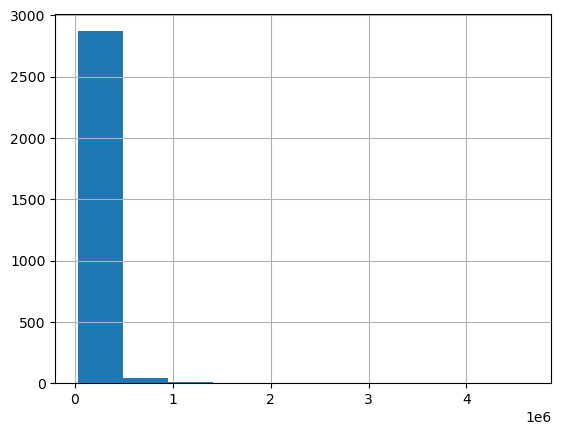

In [9]:
# Perform predictions based 
pred = data["Lot Area"]*mean
display(pred.hist())

<Axes: >

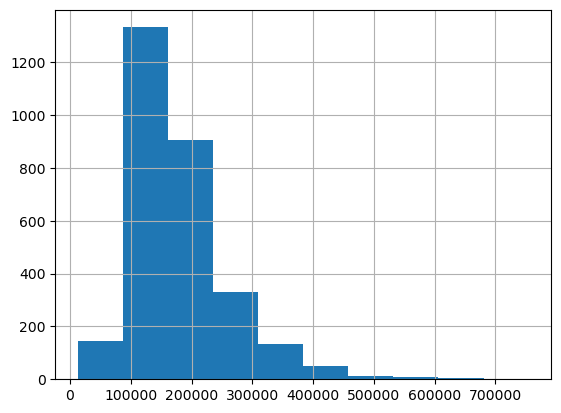

In [10]:
# Setting the ground truth labels
Y = data["SalePrice"].astype('int32')
display(Y.hist())

In [11]:
#Calculate the square error
err = Y-pred
err = err**2
display(err.mean())

29375764748.05786

In [12]:
#Doing train test split (80/20)
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [13]:
#Creating the SVR model
svr_reg = LinearSVR(random_state=0,tol=0.000001)

In [14]:
#training the model (function aproximation)
svr_reg.fit(x_train,y_train.values)

/Users/dustin/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/dustin/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVR(random_state=0, tol=1e-06)

In [15]:
#Do predictions for test set (20% of the dataset)
svr_pred = svr_reg.predict(x_test)
display(svr_pred)

array([269536.46046358, 157627.26926606, 271354.50403805, 270188.12117349,
       271124.36704611, 158555.0913209 , 271788.38451825, 158017.17593452,
       268870.78810005, 161349.46488865, 159019.180744  , 271714.12079627,
       274496.45748874, 159984.07611664, 159719.62813907, 270028.79577997,
       160060.8986621 , 159708.28296055, 274957.75033879, 159952.83836144,
       270867.89850357, 269820.45786867, 271117.55683628, 271032.14491838,
       158370.34820128, 159884.52117871, 277546.86826607, 158803.89956546,
       158583.81543742, 159257.71614836, 271015.89747781, 159355.41045532,
       273855.06123819, 268851.81450215, 160148.47522432, 274373.80314767,
       158582.01535656, 159729.94749659, 159642.82472104, 159298.29996722,
       160538.70118123, 271086.68398994, 272541.07353814, 160794.23654289,
       270469.48259453, 160643.9261974 , 160442.15608853, 158082.51322639,
       271062.38874109, 269120.72505521, 158169.22813303, 160177.5971039 ,
       269820.45251491, 2

In [16]:
#Create RF model
rf_reg = RandomForestRegressor(max_depth=2,random_state=0)

In [17]:
#Training the RF model
rf_reg.fit(x_train,y_train.values)

RandomForestRegressor(max_depth=2, random_state=0)

In [18]:
#Performing the prediction on the test set
rf_pred = rf_reg.predict(x_test)
display(rf_pred)

array([179749.70934025, 119022.46322941, 179749.70934025, 119022.46322941,
       119022.46322941, 179749.70934025, 179749.70934025, 140289.14653794,
       119022.46322941, 420807.66421851, 265835.1853983 , 265835.1853983 ,
       119022.46322941, 122515.0637727 , 119022.46322941, 179749.70934025,
       128322.28166613, 179749.70934025, 119022.46322941, 119022.46322941,
       179749.70934025, 119022.46322941, 179749.70934025, 179749.70934025,
       179749.70934025, 265835.1853983 , 420807.66421851, 179749.70934025,
       179749.70934025, 260396.13337925, 179749.70934025, 119022.46322941,
       179749.70934025, 119022.46322941, 119022.46322941, 119022.46322941,
       179749.70934025, 265835.1853983 , 179749.70934025, 265835.1853983 ,
       331414.88449207, 265835.1853983 , 265835.1853983 , 179749.70934025,
       119022.46322941, 368766.94905371, 179749.70934025, 179099.42397   ,
       179749.70934025, 119022.46322941, 179749.70934025, 119022.46322941,
       119022.46322941, 1

In [19]:
#Displaying ground truth labels
display(y_test)

Order
1358    161000
2368    116000
2823    196500
2127    123600
1545    126000
         ...  
2269    187500
457     552000
463     173000
2169    118500
1489    147500
Name: SalePrice, Length: 586, dtype: int32

In [20]:
import sklearn.metrics as met

In [21]:
#Calculate MAE metric
display(met.mean_absolute_error(y_true=y_test,y_pred=svr_pred))
display(met.mean_absolute_error(y_true=y_test,y_pred=rf_pred))

95295.49936876413

20138.484387472487

In [22]:
#Calculate R2 score metric
display(met.r2_score(y_true=y_test,y_pred=svr_pred))
display(met.r2_score(y_true=y_test,y_pred=rf_pred))

-0.8057250526383355

0.8982267888045794